In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("PBL_final.csv")
df.head()

,Review_ID,Product_Name,Category,Brand,Price_INR,Rating,Review_Title,Review_Text,Review_Date,Verified_Purchase,Helpful_Votes,Location,Device_Age_Months,Would_Recommend
0,1,Galaxy M14,Smartphone,Samsung,17056,3.1,Worst experience,totally waste of money,2024-09-08,No,37,Kolkata,12,2
1,2,Noise ColorFit Pro,Smartwatch,Noise,31694,1.0,Not satisfied,super fast smooth performance,2024-04-12,Yes,1,Jaipur,5,0
2,3,JBL Flip 5,Speaker,JBL,49575,3.1,Good product,display ok speakers average,2024-10-23,Unknown,31,Pune,11,0
3,5,HP Pavilion 15,Laptop,HP,58076,5.0,Not satisfied,stopped working after months very bad,2024-02-14,No,30,Delhi,9,1
4,7,Asus Vivobook,Laptop,Asus,22379,3.1,Value for money,totally waste of money,2024-04-18,No,23,Chennai,7,1


In [4]:
def rating_to_sentiment(r):
    if r <= 2:
        return "Negative"
    elif r == 3:
        return "Neutral"
    else:
        return "Positive"

df['Sentiment'] = df['Rating'].apply(rating_to_sentiment)

In [5]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df['clean_text'] = df['Review_Text'].apply(clean_text)

In [6]:
train_df, test_df = train_test_split(
    df, test_size=0.3, random_state=42
)

In [7]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_text_train = vectorizer.fit_transform(train_df['clean_text'])
X_text_test = vectorizer.transform(test_df['clean_text'])

In [8]:
X_train = np.hstack((X_text_train.toarray(), train_df[['Rating']].values))
X_test = np.hstack((X_text_test.toarray(), test_df[['Rating']].values))

In [9]:
y_train = train_df['Sentiment']
y_test = test_df['Sentiment']

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [27]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [28]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [17]:
def evaluate(y_test, y_pred, name):
    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate(y_test, y_pred_lr, "Logistic Regression")
evaluate(y_test, y_pred_knn, "KNN")
evaluate(y_test, y_pred_svm, "SVM")


 Logistic Regression
Accuracy: 0.8629032258064516
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        50
     Neutral       0.00      0.00      0.00        34
    Positive       0.83      1.00      0.91       164

    accuracy                           0.86       248
   macro avg       0.61      0.67      0.64       248
weighted avg       0.75      0.86      0.80       248


 KNN
Accuracy: 0.9758064516129032
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        50
     Neutral       1.00      0.82      0.90        34
    Positive       0.96      1.00      0.98       164

    accuracy                           0.98       248
   macro avg       0.99      0.94      0.96       248
weighted avg       0.98      0.98      0.97       248


 SVM
Accuracy: 0.8629032258064516
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        50
     Neu

In [18]:
classes = ["Negative", "Neutral", "Positive"]

y_test_bin = label_binarize(y_test, classes=classes)

In [19]:
y_score_lr = lr.predict_proba(X_test)

In [20]:
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

y_score_svm = svm.predict_proba(X_test)

In [21]:
y_score_knn = knn.predict_proba(X_test)

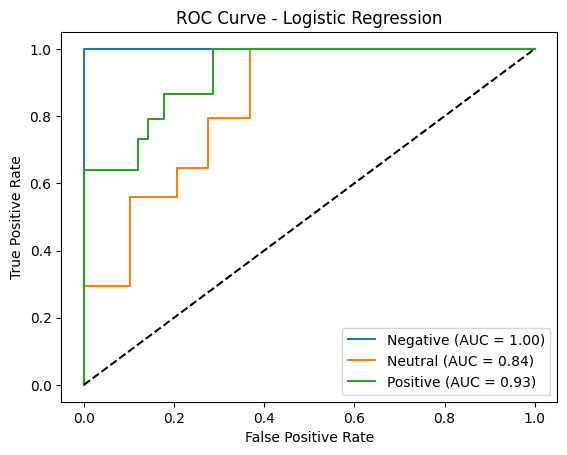

In [22]:
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_lr[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()